# Define jaggedness

In this notebook we will present progressively better definitions of "jaggedness" (actual name pending).

This is a measure that allows us to predict the way in which a defect may spread through a network, based on the LLNA's local update rule and the the networks' degree distribution.

## General principles

In the context of LLNAs, introducing a single defect has two effects:
1. The node that changes state will obey a different update rule
2. The nodes in the changed node's neighbourhood will experience a change in their neighbourhood's state density

These changes can have a big effect or a small effect on the dynamics of the system.

## The naive definition

In [2]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

%load_ext autoreload
%autoreload 2

In the first definition we only look at the effect of slightly modifying the local density. In particular we look at how many opportunities the LLNA has to change its output when a defect is introduced. We quantify this by counting the number of 'borders' in the diagram of the local update rule. Some examples are listed below:

In [60]:
def naive_jaggedness(resolution, B_set, S_set):
    # make numpy array
    B_set = np.array(B_set)
    S_set = np.array(S_set)
    # turn interval index into bits
    B_set_bin = np.zeros(resolution, dtype=int)
    S_set_bin = np.zeros(resolution, dtype=int)
    if B_set.size: B_set_bin[B_set] = 1
    if S_set.size: S_set_bin[S_set] = 1
    # perform XOR with shifted arrays
    borders_B = np.logical_xor(B_set_bin[1:], B_set_bin[:-1]).sum()
    borders_S = np.logical_xor(S_set_bin[1:], S_set_bin[:-1]).sum()
    # return total number of edges
    return borders_B + borders_S

resolution = 3
born_if = [0]
survive_if = [0]
naive_jaggedness(resolution, born_if, survive_if)

2

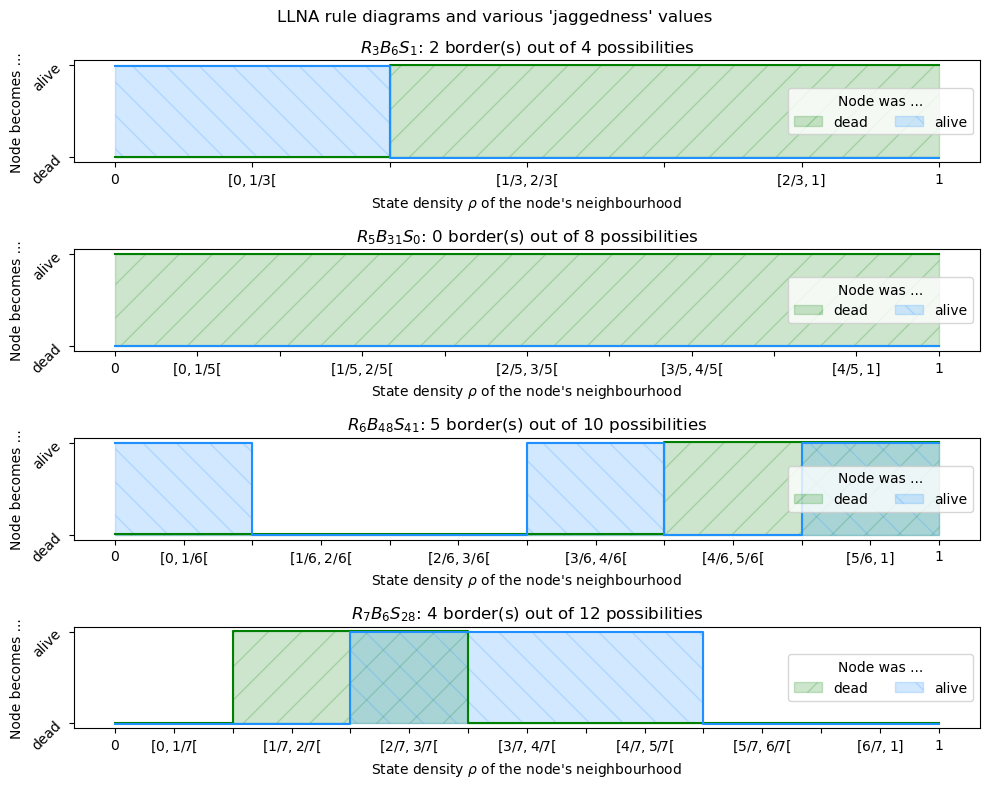

In [61]:
SAVEFIG=False

fig, axs = plt.subplots(4,1,figsize=(10, 8))

resolution = 3
born_if = [1, 2]
survive_if = [0]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[0])
borders = naive_jaggedness(resolution, born_if, survive_if)
axs[0].set_title(f"{model.__str__(latex=True)}: {borders} border(s) out of {2*(resolution-1)} possibilities")

resolution = 5
born_if = [0, 1, 2, 3, 4]
survive_if = []
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[1])
borders = naive_jaggedness(resolution, born_if, survive_if)
axs[1].set_title(f"{model.__str__(latex=True)}: {borders} border(s) out of {2*(resolution-1)} possibilities")

resolution = 6
born_if = [4, 5]
survive_if = [0, 3, 5]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[2])
borders = naive_jaggedness(resolution, born_if, survive_if)
axs[2].set_title(f"{model.__str__(latex=True)}: {borders} border(s) out of {2*(resolution-1)} possibilities")

resolution = 7
born_if = [1, 2]
survive_if = [2, 3, 4]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[3])
borders = naive_jaggedness(resolution, born_if, survive_if)
axs[3].set_title(f"{model.__str__(latex=True)}: {borders} border(s) out of {2*(resolution-1)} possibilities")

fig.suptitle("LLNA rule diagrams and various 'jaggedness' values")
fig.tight_layout()

Note:
1. We do not count the outer borders (those at $\rho = 0$ and $\rho = 1$) because they cannot be crossed.
2. The $B$ set has the same number of edges as the $B^\text{C}$ set, so the representation in the diagram does not matter.
3. There are always $2(R-1)$ possible borders.
4. There are more possibilities with an average number of borders than with a low or high number of borders.

## Add notion of changing the central node

If the central node is perturbed, the neighbourhood density is not altered, but the dynamical outcome may of course change as well. This is expressed by looking at some kind of XOR operation between the survive set and the born set

In [ ]:
def naive_jaggedness_central_node(resolution, B_set, S_set):
    # make numpy array
    B_set = np.array(B_set)
    S_set = np.array(S_set)
    # turn interval index into bits
    B_set_bin = np.zeros(resolution, dtype=int)
    S_set_bin = np.zeros(resolution, dtype=int)
    if B_set.size: B_set_bin[B_set] = 1
    if S_set.size: S_set_bin[S_set] = 1
    borders = np.logical_xor(B_set_bin, S_set_bin).sum()
    return borders

2

In this spirit, the LLNA that can maximally change the outcome is the one that is the most jagged, and for which the born set is the complement of the survive set, for example

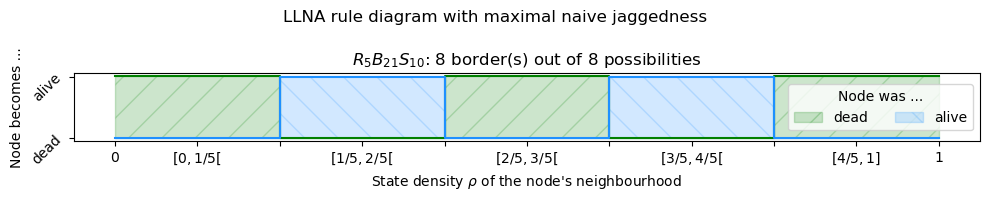

In [71]:
SAVEFIG=False

fig, ax = plt.subplots(1,1,figsize=(10, 2))

resolution = 5
born_if = [0, 2, 4]
survive_if = [1, 3]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=ax)
borders = naive_jaggedness(resolution, born_if, survive_if)
ax.set_title(f"{model.__str__(latex=True)}: {borders} border(s) out of {2*(resolution-1)} possibilities")

fig.suptitle("LLNA rule diagram with maximal naive jaggedness")
fig.tight_layout()

It is not a priori clear how we should balance these two effects: the effect of changing the neighbourhood density, and the effect of changing the central node state. Some observations include:
1. Changing the state of the central node will always have the same effect; it is not depedent on the density of the local neighbourhood (and hence not dependent on the node degree)

## Add weighing over degree distribution